In [ ]:
# \begin{table}[ht!]
#     \centering
#     \caption{Strong-scaling comparison of stage-wise speedups and efficiencies (fixed $n=2000$, $l=4$, $Nov=4$, $\kappa^*=10^5$).}
#     \label{tab:openmp-strong-template}
#     \begin{tabular}{ccccccc}
#         \hline
#         Threads $T$ & $t_{\mathrm{aux}}$ (s) & $S_{\mathrm{aux}}(T)$ & $\eta_{\mathrm{aux}}(T)$ (\%) & $t_{\mathrm{cem}}$ (s) & $S_{\mathrm{cem}}(T)$ & $\eta_{\mathrm{cem}}(T)$ (\%) \\
#         \midrule
#         No OpenMP & \texttt{8.54} & 1.00 & -- & \texttt{405.25} & 1.00 & -- \\
#         10 & \texttt{0.36} & \texttt{23.72} & \texttt{237.22} & \texttt{55.64} & \texttt{7.28} & \texttt{72.83} \\
#         20 & \texttt{0.33} & \texttt{25.88} & \texttt{129.39} & \texttt{32.53} & \texttt{12.46} & \texttt{62.29} \\
#         40 & \texttt{0.31} & \texttt{27.55} & \texttt{68.87} & \texttt{23.45} & \texttt{17.28} & \texttt{43.20} \\
#         80 & \texttt{0.35} & \texttt{24.40} & \texttt{30.50} & \texttt{20.82} & \texttt{19.46} & \texttt{24.33} \\
#         \bottomrule
#     \end{tabular}
# \end{table}

# \begin{table}[ht!]
#     \centering
#     \caption{Weak-scaling comparison of stage-wise runtimes and stage-wise weak-scaling efficiency.}
#     \label{tab:openmp-weak-template}
#     \begin{tabular}{ccccccc}
#         \hline
#          Vertices $\#\mathcal{N}$ & Subgraphs $n$ & Threads $T$ & $t_{\mathrm{aux}}$ (s) & $\eta_{\mathrm{aux}}^{\mathrm{weak}}(T)$ (\%) & $t_{\mathrm{cem}}$ (s) & $\eta_{\mathrm{cem}}^{\mathrm{weak}}(T)$ (\%) \\
#         \midrule
#          11822 & 100 & 10 & \texttt{0.14} & 100 & \texttt{3.52} & 100 \\
#          23608 & 200 & 20 & \texttt{0.18} & \texttt{155.32} & \texttt{5.19} & \texttt{135.44} \\
#          46687 & 400 & 40 & \texttt{0.29} & \texttt{190.65} & \texttt{6.83} & \texttt{203.53} \\
#          93219 & 800 & 80 & \texttt{5.34} & \texttt{20.67} & \texttt{11.46} & \texttt{242.20} \\
#         \bottomrule
#     \end{tabular}
# \end{table}

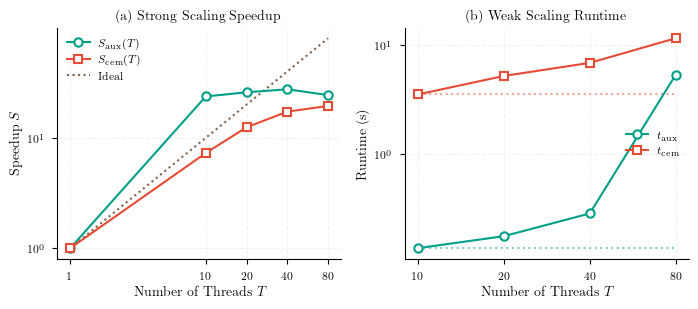

In [4]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Add the current directory to the path so we can import plot_settings
sys.path.append(os.path.abspath('.'))
from plot_settings import *

# Data parsing from the tables above
# --- Strong Scaling ---
threads_strong = np.array([1, 10, 20, 40, 80])
t_aux_strong = np.array([8.54, 0.36, 0.33, 0.31, 0.35])
t_cem_strong = np.array([405.25, 55.64, 32.53, 23.45, 20.82])

speedup_aux = t_aux_strong[0] / t_aux_strong
speedup_cem = t_cem_strong[0] / t_cem_strong

# --- Weak Scaling ---
threads_weak = np.array([10, 20, 40, 80])
t_aux_weak = np.array([0.14, 0.18, 0.29, 5.34])
t_cem_weak = np.array([3.52, 5.19, 6.83, 11.46])

# Set up figure
fig, axs = plt.subplots(1, 2, figsize=(NATURE_WIDTH, 3.2))

# Nature Publishing Group (NPG) inspired aesthetics
COLOR_AUX = '#00A087' # Teal Green
COLOR_CEM = '#E64B35' # Coral Red
COLOR_IDEAL = '#7E6148' # Muted grey-brown for ideal lines

# --- Plot Strong Scaling (Speedup) ---
ax = axs[0]
# Use hollow markers (markerfacecolor='white') for a more modern scientific look
ax.plot(threads_strong, speedup_aux, marker='o', markersize=6, markerfacecolor='white', markeredgewidth=1.5, linewidth=1.5, color=COLOR_AUX, label=r'$S_{\mathrm{aux}}(T)$')
ax.plot(threads_strong, speedup_cem, marker='s', markersize=6, markerfacecolor='white', markeredgewidth=1.5, linewidth=1.5, color=COLOR_CEM, label=r'$S_{\mathrm{cem}}(T)$')
# Ideal speedup baseline
ax.plot(threads_strong, threads_strong, linestyle=':', linewidth=1.5, color=COLOR_IDEAL, label='Ideal', zorder=0) 

ax.set_xlabel("Number of Threads $T$")
ax.set_ylabel("Speedup $S$")
ax.set_title("(a) Strong Scaling Speedup")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(threads_strong)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter()) 
ax.minorticks_off() 
ax.legend(loc='upper left', frameon=False)
ax.grid(True, which="major", ls="--", alpha=0.4, color='#DDDDDD')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Plot Weak Scaling (Runtime) ---
ax = axs[1]
ax.plot(threads_weak, t_aux_weak, marker='o', markersize=6, markerfacecolor='white', markeredgewidth=1.5, linewidth=1.5, color=COLOR_AUX, label=r'$t_{\mathrm{aux}}$')
ax.plot(threads_weak, t_cem_weak, marker='s', markersize=6, markerfacecolor='white', markeredgewidth=1.5, linewidth=1.5, color=COLOR_CEM, label=r'$t_{\mathrm{cem}}$')

# Base ideals for weak scaling
ideal_aux = [t_aux_weak[0]] * len(threads_weak)
ideal_cem = [t_cem_weak[0]] * len(threads_weak)
ax.plot(threads_weak, ideal_aux, linestyle=':', linewidth=1.5, color=COLOR_AUX, alpha=0.5, zorder=0)
ax.plot(threads_weak, ideal_cem, linestyle=':', linewidth=1.5, color=COLOR_CEM, alpha=0.5, zorder=0)

ax.set_xlabel("Number of Threads $T$")
ax.set_ylabel("Runtime (s)")
ax.set_title("(b) Weak Scaling Runtime")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(threads_weak)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.minorticks_off()
ax.legend(loc='center right', frameon=False)
ax.grid(True, which="major", ls="--", alpha=0.4, color='#DDDDDD')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save as PGF
if not os.path.exists(FIGS_ROOT_PATH):
    os.makedirs(FIGS_ROOT_PATH)
fig.savefig(os.path.join(FIGS_ROOT_PATH, 'scaling.pgf'), bbox_inches='tight')

plt.show()